## Confidence Calibration Analysis of ChatGPT-4o and Gemini-3.5 
#### Objective

The objective of this experiment is to investigate the relationship between self-reported confidence and actual correctness in a large language model. In particular, we aim to identify instances where the model produces incorrect answers with high confidence, a behavior commonly associated with hallucinations and overconfidence.

#### Experimental Setup
**Benchmark size:** 30 questions


**Question categories:**
Mathematical reasoning
Tokenization tasks
Adversarial and challenging prompts

For each question, the model was instructed to provide:
**An answer**
**A confidence score between 0 and 100**

Responses were manually verified against ground-truth answers.

#### Metrics
**Accuracy**: Fraction of correctly answered questions.

**Average Confidence**: Mean self-reported confidence across all responses.

**Overconfidence Gap**: Difference between average confidence and actual accuracy.

**High-Confidence Wrong Rate (HCWR)**: Fraction of questions answered incorrectly while reporting confidence greater than 80%.

**Expected Calibration Error (ECE)**: Quantifies model miscalibration by comparing binned predicted probabilities to empirical accuracies.

### **Accuracy and Confidence analysis for Gemini - 3.5 (Flash)**

In [84]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot

df = pd.read_csv("results.csv")

correct = []
confidences = []

for val in df["Gemini 3.5(Flash)"]:

    if pd.isna(val):
        continue

    acc, con = val.split(",")

    correct.append(int(acc.strip()))
    confidences.append(float(con.strip())/100)

threshold = 0.8

hcwr = sum(
    1
    for c, conf in zip(correct, confidences)
    if c == 0 and conf > threshold
) / len(correct)

In [85]:
accuracy = sum(correct)/len(correct)

avg_con= sum(confidences)/len(confidences)

print(f"Accuracy:{accuracy: .3f} " f"Confidence:{avg_con: .3f} " f"Gap:{avg_con-accuracy: .3f}")
print(f"HCWR: {hcwr: .3f}")


Accuracy: 0.767 Confidence: 0.985 Gap: 0.218
HCWR:  0.200


In [120]:
bins = [
    (0.0, 0.7),
    (0.7, 0.8),
    (0.8, 0.85),
    (0.85, 0.9),
    (0.9, 0.95),
    (0.95, 0.99),
    (0.99, 1.0)
]
xs=[]
ys=[]

ece=0

for low, high in bins:
    bin_con=[]
    bin_correct=[]

    for x, y in zip(confidences, correct):
        if(low<=x<=high):
            bin_con.append(x)
            bin_correct.append(y)
        
    if len(bin_con)==0:
        con=0
        acc=0
    else:
        con=sum(bin_con)/len(bin_con)
        acc=sum(bin_correct)/len(bin_correct)

    #calculate ECE
    weight=len(bin_con)/len(confidences)
    gap=abs(con-acc)

    ece+=weight*gap
        
    xs.append(con)
    ys.append(acc)
    print(f"bin: {low, high}-> " f"{con: .3f}  " f"{acc: .3f} " f"{weight*gap: .3f}")

print(f"Expected Calibration Error-> {ece: .3f}")



bin: (0.0, 0.7)->  0.000   0.000  0.000
bin: (0.7, 0.8)->  0.800   0.000  0.027
bin: (0.8, 0.85)->  0.800   0.000  0.027
bin: (0.85, 0.9)->  0.900   0.000  0.030
bin: (0.9, 0.95)->  0.938   0.500  0.058
bin: (0.95, 0.99)->  0.950   0.667  0.028
bin: (0.99, 1.0)->  1.000   0.840  0.133
Expected Calibration Error->  0.303


#### Results:

**Accuracy:**	                                76.7%

**Average Confidence:**	                        98.5%

**Overconfidence Gap:**	                        21.8%

**HCWR:**	                                    20.0%

**ECE:**                                        30.3%


### **Accuracy and Confidence analysis for ChatGPT-4o**

In [125]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyplot

correct2 = []
confidences2 = []

for val in df["ChatGPT 4o"]:

    if pd.isna(val):
        continue

    acc, con = val.split(",")

    correct2.append(int(acc.strip()))
    confidences2.append(float(con.strip())/100)

threshold = 0.8

hcwr2 = sum(
    1
    for c, conf in zip(correct2, confidences2)
    if c == 0 and conf > threshold
) / len(correct2)

In [126]:
accuracy2 = sum(correct2)/len(correct2)

avg_con2= sum(confidences2)/len(confidences2)

print(f"Accuracy:{accuracy2: .3f} " f"Confidence:{avg_con2: .3f} " f"Gap:{avg_con2-accuracy2: .3f}")
print(f"HCWR: {hcwr2: .3f}")


Accuracy: 0.700 Confidence: 0.981 Gap: 0.281
HCWR:  0.267


In [133]:
bins2 = [
    (0.0, 0.7),
    (0.7, 0.8),
    (0.8, 0.85),
    (0.85, 0.95),
    (0.95, 1.0)
]
xs2=[]
ys2=[]

ece2=0

for low, high in bins2:
    bin_con=[]
    bin_correct=[]

    for x, y in zip(confidences2, correct2):
        if(low<=x<=high):
            bin_con.append(x)
            bin_correct.append(y)
        
    if len(bin_con)==0:
        con=0
        acc=0
    else:
        con=sum(bin_con)/len(bin_con)
        acc=sum(bin_correct)/len(bin_correct)

    #calculate ECE
    weight=len(bin_con)/len(confidences2)
    gap=abs(con-acc)

    ece2+=weight*gap
        
    xs2.append(con)
    ys2.append(acc)
    print(f"bin: {low, high}-> " f"{con: .3f}  " f"{acc: .3f} " f"{weight*gap: .3f}")

print(f"Expected Calibration Error-> {ece2: .3f}")



bin: (0.0, 0.7)->  0.700   0.000  0.023
bin: (0.7, 0.8)->  0.700   0.000  0.023
bin: (0.8, 0.85)->  0.850   1.000  0.005
bin: (0.85, 0.95)->  0.917   0.333  0.058
bin: (0.95, 1.0)->  0.995   0.714  0.262
Expected Calibration Error->  0.372


#### Results:

**Accuracy:**	                                70.0%

**Average Confidence:**	                        98.1%

**Overconfidence Gap:**	                        28.1%

**HCWR:**	                                    26.7%

**ECE:**                                        37.2%

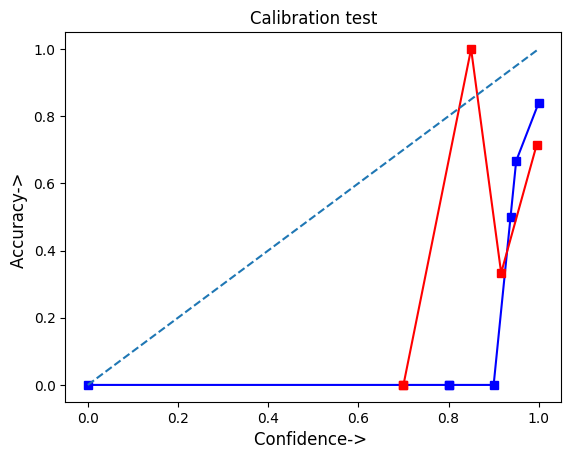

In [134]:
pyplot.xlabel('Confidence-> ', fontsize=12) 
pyplot.ylabel('Accuracy-> ', fontsize=12) 
pyplot.title('Calibration test') 

pyplot.plot(xs, ys, 'bs-') 
pyplot.plot(xs2, ys2, 'rs-')
pyplot.plot([0, 1], [0, 1], '--') 
pyplot.show()

### Reliability Diagram Analysis

The reliability diagram compares the calibration behavior of Gemini 3.5 Flash and GPT-4o across different confidence intervals. In a perfectly calibrated system, all points would lie on the diagonal line, indicating that reported confidence matches observed accuracy.

Both models exhibit a strong tendency to assign very high confidence scores, with the majority of predictions concentrated in the 0.90–1.00 confidence range. This indicates that both models rarely express uncertainty, even when answering challenging questions.

However, neither model follows the ideal calibration line closely. Significant deviations from the diagonal suggest that reported confidence is not always a reliable indicator of actual correctness.

#### Gemini 3.5 Flash

The Gemini calibration curve remains consistently below the ideal calibration line in the high-confidence region. Despite assigning confidence values close to 100% for most responses, the observed accuracy remains substantially lower. This pattern indicates systematic overconfidence, where confidence estimates exceed true performance.

The relatively smooth shape of the Gemini curve suggests a stable but poorly calibrated confidence assignment strategy, with the model frequently expressing near-certainty even when errors occur.

#### GPT-4o

GPT-4o exhibits greater variability across confidence bins. While some high-confidence regions achieve near-perfect accuracy, other similarly confident regions experience sharp drops in performance. This results in a less stable calibration profile, indicating that confidence estimates are not consistently aligned with correctness.

The fluctuations observed in the GPT-4o curve are likely influenced by the concentration of predictions within a narrow confidence range. Nevertheless, the diagram suggests that GPT-4o's confidence behavior is more heterogeneous than Gemini's, with certain confidence intervals appearing better calibrated than others.

#### Comparative Insights
Both models are heavily concentrated in the high-confidence regime (≥ 0.9).
Neither model achieves perfect calibration, as both deviate noticeably from the ideal diagonal.
Gemini displays a more consistent pattern of overconfidence across bins.
GPT-4o shows greater calibration variability, achieving strong calibration in some confidence intervals while exhibiting substantial miscalibration in others.
The results suggest that high confidence should not be interpreted as a guarantee of correctness for either model on this benchmark.

**Key Observation:** Both Gemini 3.5 Flash and GPT-4o demonstrate calibration deficiencies, with most predictions concentrated near maximum confidence despite lower empirical accuracy. Gemini exhibits a more uniformly overconfident behavior, whereas GPT-4o shows greater variability across confidence levels. Overall, the reliability diagram indicates that self-reported confidence is an imperfect proxy for actual correctness for both models on the evaluated benchmark.